In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [2]:
class AgentState(TypedDict):
    number1: int
    operation: str
    number2: int
    finalNumber: int

In [3]:
def adder(state:AgentState) -> AgentState:
    """ Addition operation """
    state['finalNumber'] = state['number1'] + state['number2']
    return state

In [4]:
def subtractor(state: AgentState) -> AgentState:
    """ Subtraction operation """
    state['finalNumber'] = state['number1'] - state['number2']
    return state

In [5]:
def decision_node(state: AgentState) -> str:
    """ Decision node """
    if state['operation'] == '+':
        return "addition_operation"
    elif state['operation'] == '-':
        return "subtraction_operation"

In [8]:
graph = StateGraph(AgentState)

graph.add_node("add_node",adder)
graph.add_node("sub_node",subtractor)
graph.add_node("router",lambda state:state)

graph.add_edge(START,"router")
graph.add_conditional_edges(
    "router",
    decision_node,
    {
        "addition_operation": "add_node",
        "subtraction_operation": "sub_node"
    }
)
graph.add_edge("add_node",END)
graph.add_edge("sub_node",END)

app = graph.compile()

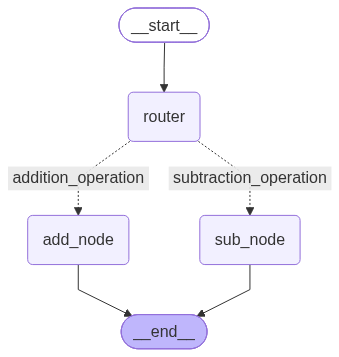

In [9]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [10]:
initial_state_1 = AgentState(number1 = 10, operation="-", number2 = 5)
print(app.invoke(initial_state_1))

{'number1': 10, 'operation': '-', 'number2': 5, 'finalNumber': 5}


In [11]:
result = app.invoke({"number1": 10, "operation": "-", "number2": 5})
print(result)

{'number1': 10, 'operation': '-', 'number2': 5, 'finalNumber': 5}
